Scipy Uses Maximum Likelihood to estimate model parameters for fitting data to a distribution.

In [1]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fit a normal distribution

In [2]:
data = np.random.normal(loc=5, scale=2, size=1000)
mu, std = norm.fit(data)

print(f'Esimated mean: {mu}, Estimated std deviation: {std}')

Esimated mean: 5.045675400103744, Estimated std deviation: 1.9066954434617527


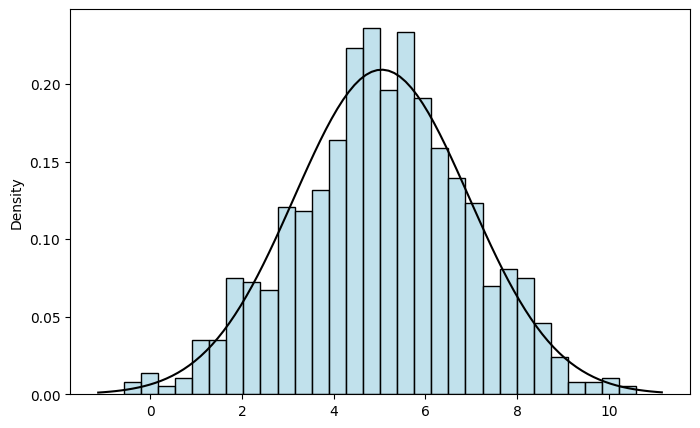

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(data, bins=30, stat='density', kde=False, color='lightblue')
x_min, x_max = plt.xlim()
x = np.linspace(x_min, x_max,100)
plt.plot(x, norm.pdf(x, mu, std), color='black')

# Fit a gamma distribution

In [4]:
#Generate sample data

from scipy.stats import gamma

data = gamma.rvs(a=2, scale=2, size=1000, random_state=0)

shape, loc, scale = gamma.fit(data)

shape, loc, scale

(np.float64(2.1147256745542338),
 np.float64(0.01494851153889738),
 np.float64(1.8518744637181082))

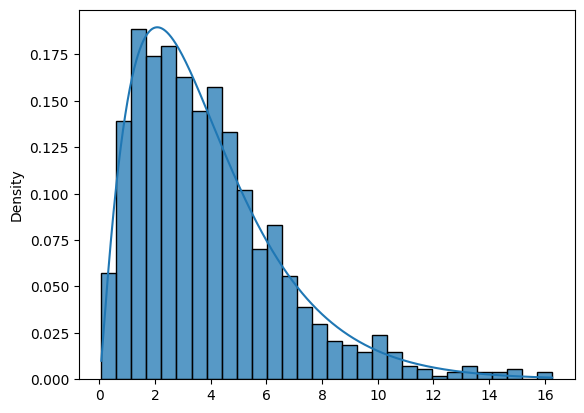

In [5]:
sns.histplot(data, bins=30, stat='density')

x = np.linspace(min(data), max(data), 1000)
plt.plot(x, gamma.pdf(x, shape, loc=loc, scale=scale))

# Q-Q Plot

A Q-Q plot compares quantiles of your data against the quantiles of a theoretical distribution.
If points lie approximately on a straight line, the fit is good.

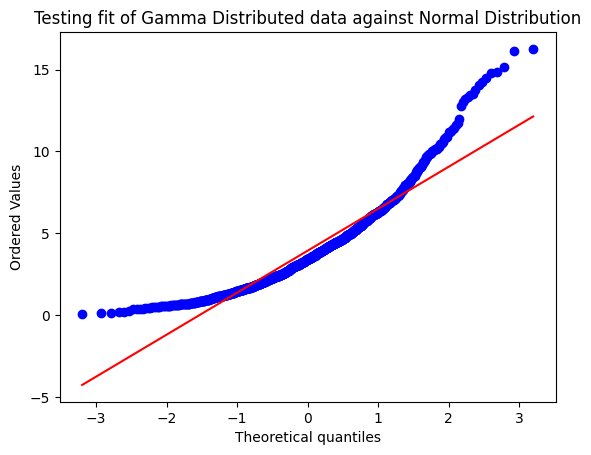

In [6]:
import scipy.stats as stats

stats.probplot(data, dist='norm', plot=plt);
plt.title('Testing fit of Gamma Distributed data against Normal Distribution');

# Fitting parameters on Iris dataset

In [7]:
from sklearn import datasets
import matplotlib.pyplot as plt

iris = datasets.load_iris()

X = iris['data']
y = iris['target']

In [8]:
select_feature = X[:,2]

<Figure size 1200x1000 with 0 Axes>

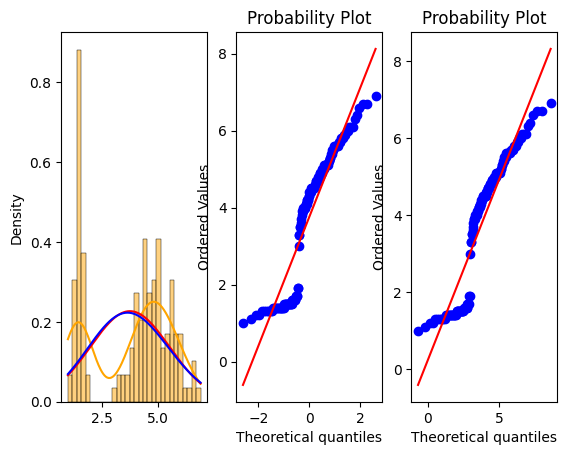

In [41]:
from scipy.stats import gamma

plt.figure(figsize=(12,10))
fig, ax = plt.subplots(1,3)
sns.histplot(select_feature, bins=30, kde=True, stat='density', color='orange', label='Data', ax=ax[0]);

mu, std = norm.fit(select_feature)
x = np.linspace(select_feature.min(), select_feature.max(), 1000)
ax[0].plot(x, norm.pdf(x, mu, std), 'r-', label='Normal Fit')

shape, loc, scale = gamma.fit(select_feature)
ax[0].plot(x, gamma.pdf(x, shape, loc=loc, scale=scale), 'b-', label='Gamma Fit')


stats.probplot(select_feature, dist='norm', plot=ax[1]);
stats.probplot(select_feature, dist='gamma', sparams=(shape, loc, scale), plot=ax[2]);

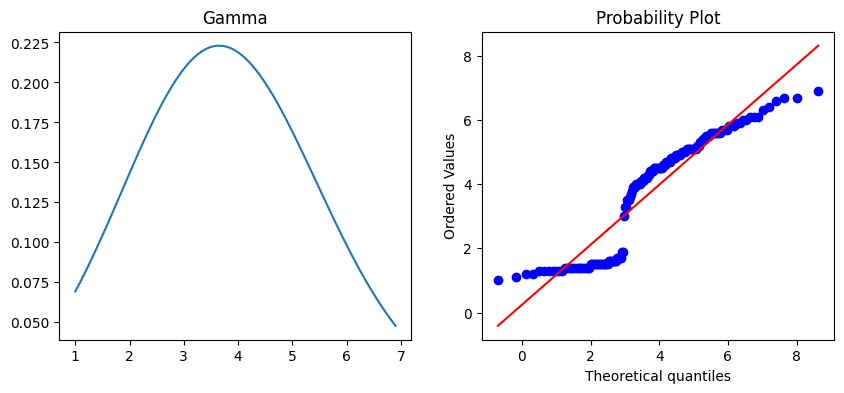